# Instructor Notebook 01 — Machine Learning
**ComplianceGPT Lab · REU 2026 · Week 2**

> **Teaching script:** Run every cell top-to-bottom. All outputs are deterministic (`random_state=42` fixed everywhere). Each visual appears right after the concept it illustrates.

**Learning arc:**
1. What ML actually is — data replaces rules
2. FIFA 2014 scatter plot — build intuition visually
3. Three algorithms — accuracy comparison chart
4. Decision Tree — readable rules + diagram
5. Feature importance — which stats actually predict success?
6. Confusion matrices — understanding errors
7. Pivot to HIPAA — expose the feature extraction wall

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import json, warnings
warnings.filterwarnings('ignore')

# Consistent color palette
C_YES   = '#990000'   # crimson — top 8 / PERMITTED
C_NO    = '#003366'   # navy   — knocked out / DENIED
C_GOLD  = '#f0a500'
C_GREEN = '#1f7a3c'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   1.2,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print('✓ Libraries loaded.')

✓ Libraries loaded.


---
## Part 1 · The Core Idea

> **Say:** "Before ML, you wrote rules by hand: `if 'court order' in text: PERMITTED`. The problem — 200 rules, every edge case breaks something, 'judicial mandate' slips through. ML inverts this: you show the algorithm labeled examples, it discovers the rules itself."

The three ingredients:
- **Features** — numeric representation of your input  
- **Labels** — the correct answer for each example  
- **Algorithm** — finds the pattern from (features, labels) pairs

---
## Part 2 · FIFA 2014 — Visual Intuition First

We're going to use FIFA 2014 World Cup data. 32 teams. 7 stats per team. Can an algorithm predict which 8 teams made the quarterfinals just from those stats?

Before we train anything — let's just *look* at the data. Visualization is always step 1 in ML.

In [48]:
FIFA_PATH = '/Users/priscilladanso/Downloads/FIFA - 2014.csv'

fifa = pd.read_csv(FIFA_PATH)
fifa['Goal Difference'] = pd.to_numeric(
    fifa['Goal Difference'].astype(str).str.replace('\u2212', '-'), errors='coerce'
)
fifa['top8'] = (fifa['Games Played'] >= 5).astype(int)

fifa

,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,top8
0,1,Germany,7,6,1,0,18,4,14,19,1
1,2,Argentina,7,5,1,1,8,4,4,16,1
2,3,Netherlands,7,5,2,0,15,4,11,17,1
3,4,Brazil,7,3,2,2,11,14,-3,11,1
4,5,Colombia,5,4,0,1,12,4,8,12,1
5,6,Belgium,5,4,0,1,6,3,3,12,1
6,7,France,5,3,1,1,10,3,7,10,1
7,8,Costa Rica,5,2,3,0,5,2,3,9,1
8,9,Chile,4,2,1,1,6,4,2,7,0
9,10,Mexico,4,2,1,1,5,3,2,7,0


In [ ]:
print(f'Loaded {len(fifa)} teams  |  Top-8: {fifa["top8"].sum()}  |  Knocked out: {(1-fifa["top8"]).sum()}')
print()
print(fifa[['Position','Team','Win','Draw','Loss','Goals For','Goals Against','Goal Difference','Points','top8']]
      .rename(columns={'top8':'QF?'})
      .to_string(index=False))

In [63]:
import requests
from bs4 import BeautifulSoup

results = requests.get('https://www.iban.com/country-codes')
soup = BeautifulSoup(results.content, 'lxml')
table = soup.table

code_df = pd.read_html(table.prettify())[0]
code_df

,Country,Alpha-2 code,Alpha-3 code,Numeric
0,Afghanistan,AF,AFG,4
1,Åland Islands,AX,ALA,248
2,Albania,AL,ALB,8
3,Algeria,DZ,DZA,12
4,American Samoa,AS,ASM,16
...,...,...,...,...
244,Wallis and Futuna,WF,WLF,876
245,Western Sahara,EH,ESH,732
246,Yemen,YE,YEM,887
247,Zambia,ZM,ZMB,894


In [64]:
code_df = code_df.rename(columns={'Country': 'Team'})
code_df

,Team,Alpha-2 code,Alpha-3 code,Numeric
0,Afghanistan,AF,AFG,4
1,Åland Islands,AX,ALA,248
2,Albania,AL,ALB,8
3,Algeria,DZ,DZA,12
4,American Samoa,AS,ASM,16
...,...,...,...,...
244,Wallis and Futuna,WF,WLF,876
245,Western Sahara,EH,ESH,732
246,Yemen,YE,YEM,887
247,Zambia,ZM,ZMB,894


In [65]:
country_codes_df = pd.merge(fifa, code_df)
country_codes_df

,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,top8,Alpha-2 code,Alpha-3 code,Numeric
0,1,Germany,7,6,1,0,18,4,14,19,1,DE,DEU,276
1,2,Argentina,7,5,1,1,8,4,4,16,1,AR,ARG,32
2,4,Brazil,7,3,2,2,11,14,-3,11,1,BR,BRA,76
3,5,Colombia,5,4,0,1,12,4,8,12,1,CO,COL,170
4,6,Belgium,5,4,0,1,6,3,3,12,1,BE,BEL,56
5,7,France,5,3,1,1,10,3,7,10,1,FR,FRA,250
6,8,Costa Rica,5,2,3,0,5,2,3,9,1,CR,CRI,188
7,9,Chile,4,2,1,1,6,4,2,7,0,CL,CHL,152
8,10,Mexico,4,2,1,1,5,3,2,7,0,MX,MEX,484
9,11,Switzerland,4,2,0,2,7,7,0,6,0,CH,CHE,756


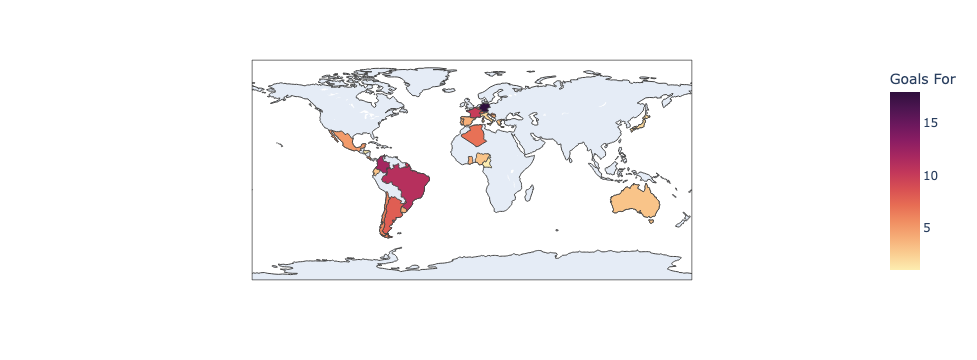

In [66]:
import plotly.express as px

fig = px.choropleth(country_codes_df, locations="Alpha-3 code", color="Goals For", hover_name="Team",color_continuous_scale="matter")
fig.show()

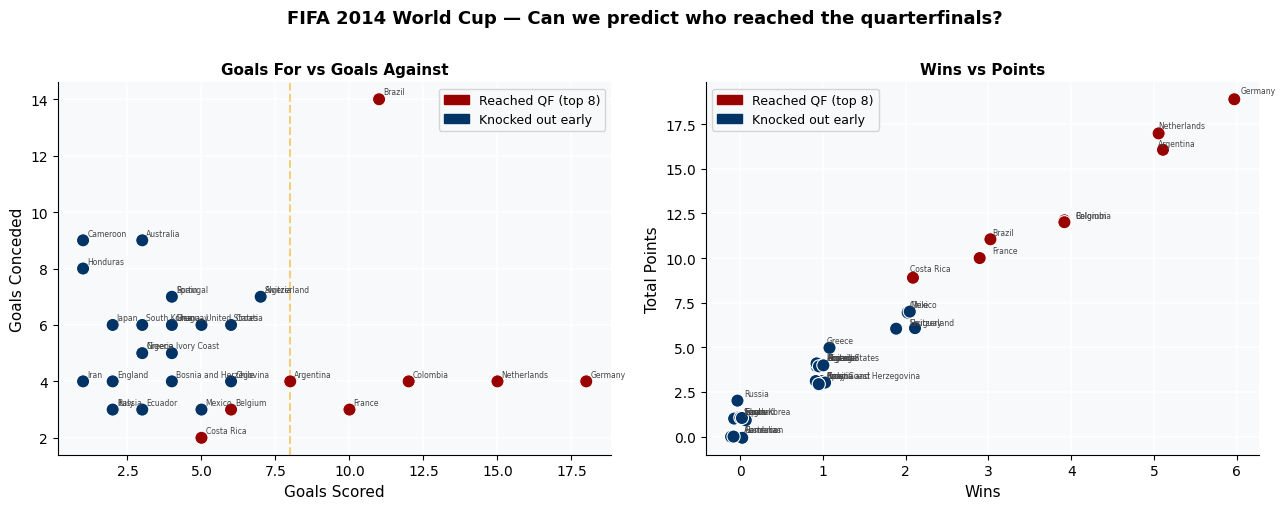


→ Even by eye you can see a boundary. Top-8 teams cluster toward high goals and wins.
  ML algorithms formalize this intuition into a precise decision rule.


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('FIFA 2014 World Cup — Can we predict who reached the quarterfinals?',
             fontsize=13, fontweight='bold', y=1.01)

colors = [C_YES if t else C_NO for t in fifa['top8']]
labels_text = ['Quarterfinal (top 8)', 'Knocked out early']
patches = [
    mpatches.Patch(color=C_YES, label='Reached QF (top 8)'),
    mpatches.Patch(color=C_NO,  label='Knocked out early'),
]

# Plot 1 — Goals For vs Goals Against
ax = axes[0]
ax.scatter(fifa['Goals For'], fifa['Goals Against'],
           c=colors, s=90, edgecolors='white', linewidths=0.8, zorder=3)
for _, row in fifa.iterrows():
    ax.annotate(row['Team'], (row['Goals For'], row['Goals Against']),
                fontsize=5.5, ha='left', va='bottom',
                xytext=(3, 2), textcoords='offset points', color='#444')
ax.set_xlabel('Goals Scored', fontsize=11)
ax.set_ylabel('Goals Conceded', fontsize=11)
ax.set_title('Goals For vs Goals Against', fontsize=11, fontweight='bold')
ax.legend(handles=patches, fontsize=9, loc='upper right')
ax.axvline(x=8, color=C_GOLD, linestyle='--', alpha=0.5, label='rough boundary')

# Plot 2 — Points vs Win
ax = axes[1]
jitter_x = np.random.RandomState(42).uniform(-0.12, 0.12, len(fifa))
jitter_y = np.random.RandomState(7).uniform(-0.12, 0.12, len(fifa))
ax.scatter(fifa['Win'] + jitter_x, fifa['Points'] + jitter_y,
           c=colors, s=90, edgecolors='white', linewidths=0.8, zorder=3)
for _, row in fifa.iterrows():
    ax.annotate(row['Team'], (row['Win'], row['Points']),
                fontsize=5.5, ha='left', va='bottom',
                xytext=(3, 2), textcoords='offset points', color='#444')
ax.set_xlabel('Wins', fontsize=11)
ax.set_ylabel('Total Points', fontsize=11)
ax.set_title('Wins vs Points', fontsize=11, fontweight='bold')
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.show()
print()
print('→ Even by eye you can see a boundary. Top-8 teams cluster toward high goals and wins.')
print('  ML algorithms formalize this intuition into a precise decision rule.')

### Build Feature Matrix

We exclude `Games Played` — that would be cheating, it directly encodes our label. Everything else becomes a feature.

Looking at those scatter plots — which feature do you think an algorithm will weight most heavily?

In [35]:
FEATURES = ['Win', 'Draw', 'Loss', 'Goals For', 'Goals Against', 'Goal Difference', 'Points']

X = fifa[FEATURES].values
y = fifa['top8'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix X: {X.shape}  (32 teams × 7 features)')
print(f'Label vector y:   {y.shape}  (0=knocked out, 1=quarterfinal)')
print()
print(pd.DataFrame(X, columns=FEATURES, index=fifa['Team']).to_string())

Feature matrix X: (32, 7)  (32 teams × 7 features)
Label vector y:   (32,)  (0=knocked out, 1=quarterfinal)

                        Win  Draw  Loss  Goals For  Goals Against  Goal Difference  Points
Team                                                                                      
Germany                   6     1     0         18              4               14      19
Argentina                 5     1     1          8              4                4      16
Netherlands               5     2     0         15              4               11      17
Brazil                    3     2     2         11             14               -3      11
Colombia                  4     0     1         12              4                8      12
Belgium                   4     0     1          6              3                3      12
France                    3     1     1         10              3                7      10
Costa Rica                2     3     0          5              2       

---
## Part 3 · Three Algorithms — Same Data, Different Approach

Same 7 features. Same labels. Three algorithms. The only thing that changes is HOW each one finds the decision boundary.

In [36]:
lr = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

model_dict = {
    'Logistic Regression': (lr, X_scaled),
    'Decision Tree':       (dt, X),
    'Random Forest':       (rf, X),
}

cv_results = {}
for name, (model, X_in) in model_dict.items():
    model.fit(X_in, y)
    scores = cross_val_score(model, X_in, y, cv=5, scoring='accuracy')
    cv_results[name] = scores

print(f"{'Model':<25} {'CV Accuracy':>12} {'Std':>8}")
print('-' * 50)
for name, scores in cv_results.items():
    print(f'{name:<25} {scores.mean():>12.1%} {scores.std():>8.3f}')
print()
print('Note: only 32 samples — CV variance is high. Treat as rough intuition.')

Model                      CV Accuracy      Std
--------------------------------------------------
Logistic Regression              90.5%    0.078
Decision Tree                    94.3%    0.114
Random Forest                    91.0%    0.117

Note: only 32 samples — CV variance is high. Treat as rough intuition.


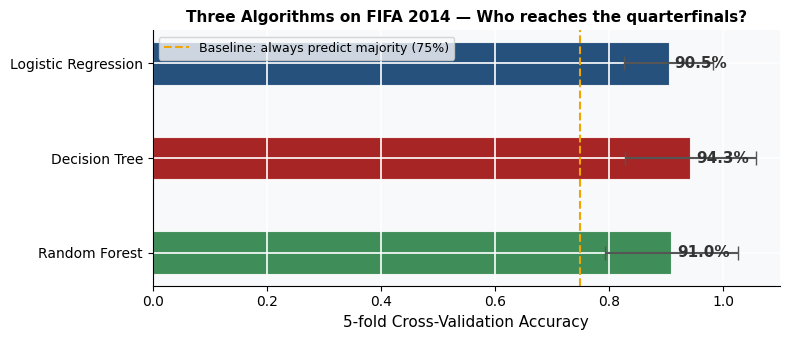

The gold dashed line is the baseline: just always predict the most common class.
All three models beat it. Error bars show variance across 5 folds.


In [37]:
fig, ax = plt.subplots(figsize=(8, 3.5))

names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors_bar = [C_NO, C_YES, C_GREEN]

bars = ax.barh(names, means, xerr=stds,
               color=colors_bar, alpha=0.85,
               error_kw=dict(ecolor='#555', lw=1.5, capsize=5),
               edgecolor='white', linewidth=0.8, height=0.45)

for bar, mean in zip(bars, means):
    ax.text(mean + 0.01, bar.get_y() + bar.get_height()/2,
            f'{mean:.1%}', va='center', fontsize=11, fontweight='bold', color='#333')

ax.set_xlim(0, 1.1)
ax.set_xlabel('5-fold Cross-Validation Accuracy', fontsize=11)
ax.set_title('Three Algorithms on FIFA 2014 — Who reaches the quarterfinals?',
             fontsize=11, fontweight='bold')
ax.axvline(x=max(y.mean(), 1-y.mean()), color=C_GOLD, linestyle='--',
           linewidth=1.5, label=f'Baseline: always predict majority ({max(y.mean(), 1-y.mean()):.0%})')
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.show()
print('The gold dashed line is the baseline: just always predict the most common class.')
print('All three models beat it. Error bars show variance across 5 folds.')

---
## Part 4 · Decision Tree — Read the Rules, Then See the Diagram

Decision Trees are special: unlike other models, you can READ what it learned. It splits data by asking yes/no questions — whichever question best separates top-8 from knocked-out.

First the rules as text, then the actual diagram.

In [38]:
print('Decision Tree Rules (max_depth=3):')
print('='*55)
print(export_text(dt, feature_names=FEATURES))
print('class labels:  class_0 = knocked out   class_1 = reached QF')

Decision Tree Rules (max_depth=3):
|--- Points <= 8.00
|   |--- class: 0
|--- Points >  8.00
|   |--- class: 1

class labels:  class_0 = knocked out   class_1 = reached QF


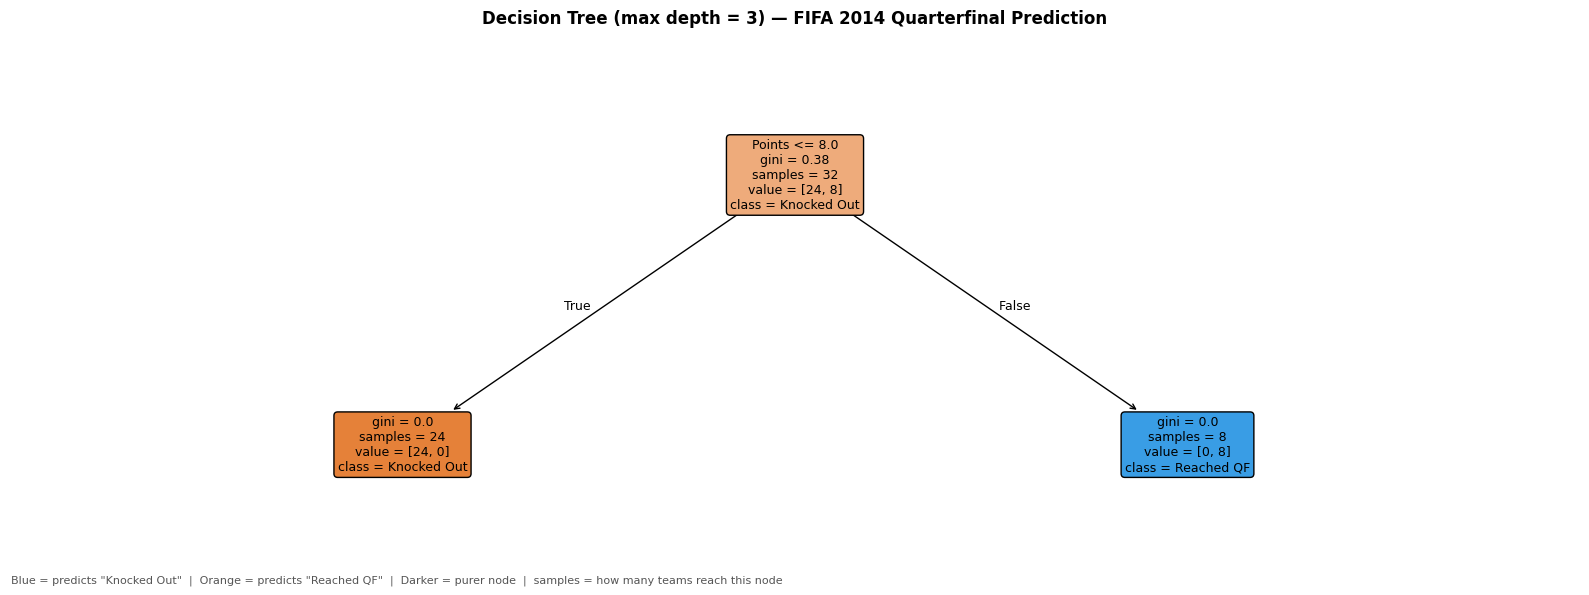


→ Each internal node shows: the split condition, Gini impurity, and sample count.
→ Leaf nodes show the final prediction (class) and how many training examples land there.
→ You can trace ANY team down the tree and explain exactly why it was classified.


In [39]:
fig, ax = plt.subplots(figsize=(16, 6))

plot_tree(
    dt,
    feature_names=FEATURES,
    class_names=['Knocked Out', 'Reached QF'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=9,
    ax=ax,
    precision=2,
)

ax.set_title('Decision Tree (max depth = 3) — FIFA 2014 Quarterfinal Prediction',
             fontsize=12, fontweight='bold', pad=12)

# Color legend
fig.text(0.01, 0.02,
         'Blue = predicts "Knocked Out"  |  Orange = predicts "Reached QF"  |  '
         'Darker = purer node  |  samples = how many teams reach this node',
         fontsize=8, color='#555')

plt.tight_layout()
plt.show()
print()
print('→ Each internal node shows: the split condition, Gini impurity, and sample count.')
print('→ Leaf nodes show the final prediction (class) and how many training examples land there.')
print('→ You can trace ANY team down the tree and explain exactly why it was classified.')

**Gini impurity** is a metric used in machine learning—specifically in decision trees—to measure how often a randomly chosen element would be incorrectly labeled if it was randomly classified according to the distribution of labels in a node

---
## Part 5 · Logistic Regression — Feature Weights

Logistic Regression assigns a learned weight to each feature. High positive weight = that feature pushes strongly toward 'Reached QF'. Negative weight = pushes toward 'Knocked Out'.

Look at the chart and see if your prediction from the scatter plots was right.

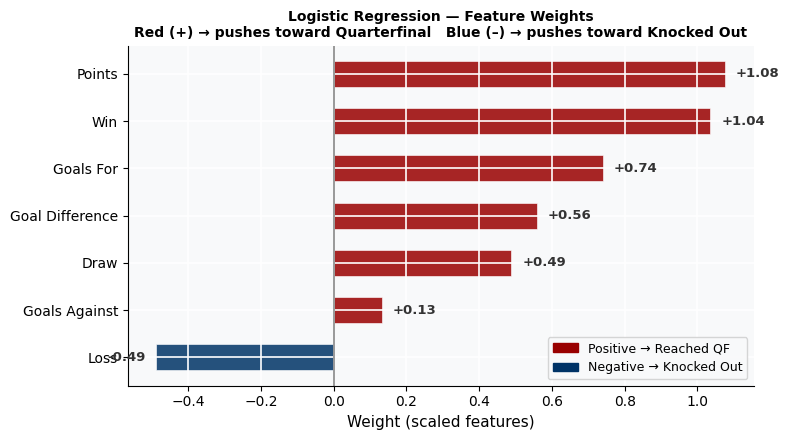


→ Goal Difference and Points dominate — makes intuitive sense.
→ Goals Against has a negative weight: conceding more goals → less likely to advance.
→ Draws are slightly negative: successful teams win outright rather than drawing.


In [40]:
weights = pd.Series(lr.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))

bar_colors = [C_YES if w > 0 else C_NO for w in weights.values]
bars = ax.barh(weights.index, weights.values,
               color=bar_colors, alpha=0.85,
               edgecolor='white', linewidth=0.5, height=0.55)

for bar, val in zip(bars, weights.values):
    offset = 0.03 if val >= 0 else -0.03
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha=ha, fontsize=9.5, fontweight='bold', color='#333')

ax.axvline(x=0, color='#888', linewidth=1.2)
ax.set_xlabel('Weight (scaled features)', fontsize=11)
ax.set_title('Logistic Regression — Feature Weights\n'
             'Red (+) → pushes toward Quarterfinal   Blue (–) → pushes toward Knocked Out',
             fontsize=10, fontweight='bold')

patches = [
    mpatches.Patch(color=C_YES, label='Positive → Reached QF'),
    mpatches.Patch(color=C_NO,  label='Negative → Knocked Out'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()
print()
print('→ Goal Difference and Points dominate — makes intuitive sense.')
print('→ Goals Against has a negative weight: conceding more goals → less likely to advance.')
print('→ Draws are slightly negative: successful teams win outright rather than drawing.')

---
## Part 6 · Random Forest — Feature Importances

> **Say:** "Random Forest trains 100 different Decision Trees, each on a random sample of data and features. Final prediction = majority vote. Feature importance = how often a feature was used to make a useful split across all 100 trees."

> **Say:** "It's more reliable than one tree's single opinion."

In [68]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances

Draw               0.019858
Goals Against      0.031565
Loss               0.049190
Goals For          0.129659
Win                0.199515
Goal Difference    0.229247
Points             0.340966
dtype: float64

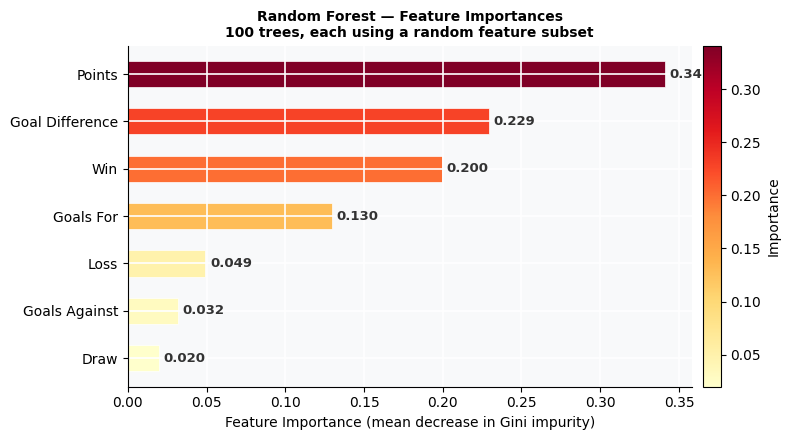


→ Importances sum to 1.0 (they are proportional contributions).
→ Compare to LR weights above: do the two algorithms agree on what matters?
→ Note: RF importances show usefulness; LR weights show direction (push for or against).


In [41]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

# Gradient colors based on importance value
norm = plt.Normalize(importances.min(), importances.max())
cmap = plt.cm.YlOrRd
bar_colors_rf = [cmap(norm(v)) for v in importances.values]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(importances.index, importances.values,
               color=bar_colors_rf, edgecolor='white', linewidth=0.5, height=0.55)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9.5, fontweight='bold', color='#333')

ax.set_xlabel('Feature Importance (mean decrease in Gini impurity)', fontsize=10)
ax.set_title('Random Forest — Feature Importances\n'
             '100 trees, each using a random feature subset',
             fontsize=10, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Importance', fraction=0.03, pad=0.02)

plt.tight_layout()
plt.show()
print()
print('→ Importances sum to 1.0 (they are proportional contributions).')
print('→ Compare to LR weights above: do the two algorithms agree on what matters?')
print('→ Note: RF importances show usefulness; LR weights show direction (push for or against).')

---
## Part 7 · Confusion Matrices — Understanding Errors

> **Say:** "Accuracy alone doesn't tell the whole story. A confusion matrix shows WHAT KIND of errors the model makes — and for HIPAA compliance, the error type matters enormously."

> **Say:** "Two types of error:"
- **False Positive** — model says 'Reached QF' but team was knocked out early
- **False Negative** — model says 'Knocked Out' but team actually made the quarterfinal

> **Say:** "In HIPAA: FP = said PERMITTED when it should be DENIED → illegal disclosure. FN = said DENIED when it should be PERMITTED → over-blocking. These have very different consequences."

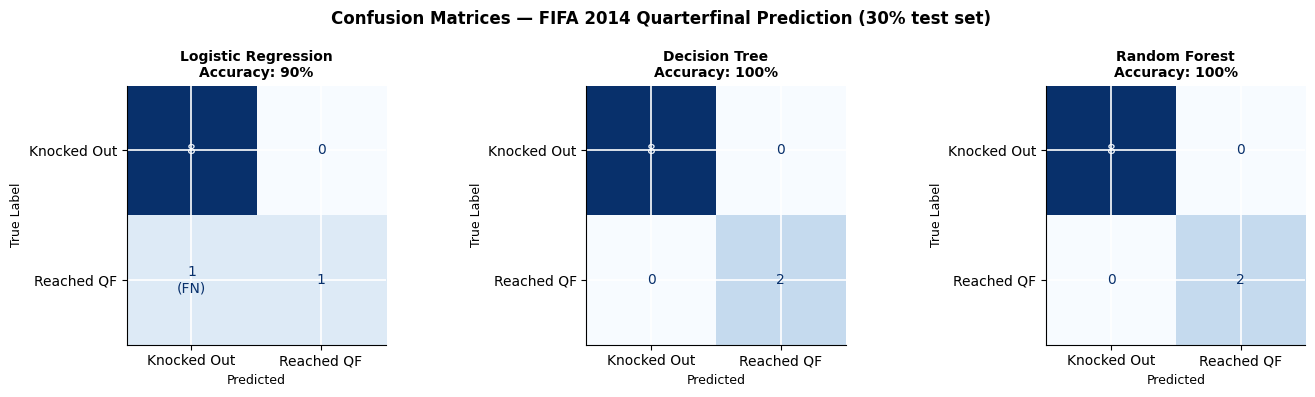


Reading a confusion matrix:
  Top-left:     True Negatives (TN) — correctly said Knocked Out
  Top-right:    False Positives (FP) — wrongly said Reached QF
  Bottom-left:  False Negatives (FN) — wrongly said Knocked Out
  Bottom-right: True Positives (TP) — correctly said Reached QF


In [42]:
# Train/test split so we can get predictions (not CV)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_tr_s, X_te_s, _, _ = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Confusion Matrices — FIFA 2014 Quarterfinal Prediction (30% test set)',
             fontsize=12, fontweight='bold')

model_inputs = [
    ('Logistic Regression', lr,  X_tr_s, X_te_s),
    ('Decision Tree',       dt,  X_tr,   X_te),
    ('Random Forest',       rf,  X_tr,   X_te),
]

for ax, (name, model, Xtr_in, Xte_in) in zip(axes, model_inputs):
    model.fit(Xtr_in, y_tr)
    preds = model.predict(Xte_in)
    cm = confusion_matrix(y_te, preds)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Knocked Out', 'Reached QF']
    )
    disp.plot(ax=ax, colorbar=False,
              cmap='Blues', values_format='d')
    acc = (preds == y_te).mean()
    ax.set_title(f'{name}\nAccuracy: {acc:.0%}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

    # Annotate FP and FN
    if cm.shape == (2,2):
        fp = cm[0, 1]
        fn = cm[1, 0]
        if fp > 0:
            ax.texts[1].set_text(f'{fp}\n(FP)')
        if fn > 0:
            ax.texts[2].set_text(f'{fn}\n(FN)')

plt.tight_layout()
plt.show()
print()
print('Reading a confusion matrix:')
print('  Top-left:     True Negatives (TN) — correctly said Knocked Out')
print('  Top-right:    False Positives (FP) — wrongly said Reached QF')
print('  Bottom-left:  False Negatives (FN) — wrongly said Knocked Out')
print('  Bottom-right: True Positives (TP) — correctly said Reached QF')

### Precision, Recall, F1

> **Say:** "These three metrics capture the tradeoff between false positives and false negatives. This is the framework we'll use to evaluate the HIPAA system too."

In [43]:
# Retrain on all data then compute precision/recall/F1 on train
# (illustrative — 32 samples too small for real train/test split)
print('Classification Report — Random Forest (trained on all 32 teams):')
rf.fit(X, y)
preds_all = rf.predict(X)
print(classification_report(y, preds_all, target_names=['Knocked Out', 'Reached QF']))
print()
print('Key formulas:')
print('  Precision = TP / (TP + FP)  — when we say YES, how often are we right?')
print('  Recall    = TP / (TP + FN)  — of all real YES cases, how many did we catch?')
print('  F1        = 2 × (Precision × Recall) / (Precision + Recall)  — harmonic mean')

Classification Report — Random Forest (trained on all 32 teams):
              precision    recall  f1-score   support

 Knocked Out       1.00      1.00      1.00        24
  Reached QF       1.00      1.00      1.00         8

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32


Key formulas:
  Precision = TP / (TP + FP)  — when we say YES, how often are we right?
  Recall    = TP / (TP + FN)  — of all real YES cases, how many did we catch?
  F1        = 2 × (Precision × Recall) / (Precision + Recall)  — harmonic mean


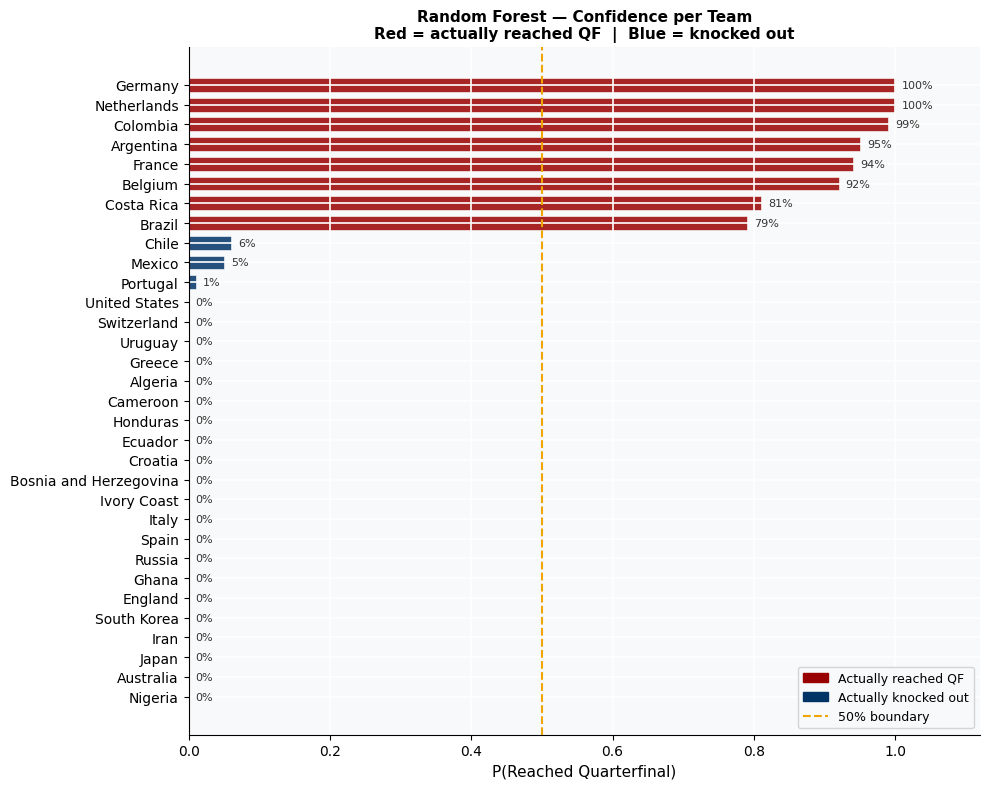


→ Teams left of the dashed line are predicted knocked out; right = predicted QF.
→ Misclassified teams: bars on wrong side of boundary.


In [44]:
# Probability calibration chart — confidence per team
rf.fit(X, y)
probs = rf.predict_proba(X)[:, 1]  # P(top8)
prob_df = pd.DataFrame({'Team': fifa['Team'], 'P(QF)': probs, 'top8': fifa['top8']})
prob_df = prob_df.sort_values('P(QF)', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
bar_c = [C_YES if t else C_NO for t in prob_df['top8']]

bars = ax.barh(prob_df['Team'], prob_df['P(QF)'],
               color=bar_c, alpha=0.85, height=0.7,
               edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, prob_df['P(QF)']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.0%}', va='center', fontsize=8, color='#333')

ax.axvline(x=0.5, color=C_GOLD, linestyle='--', linewidth=1.5, label='Decision boundary (50%)')
ax.set_xlim(0, 1.12)
ax.set_xlabel('P(Reached Quarterfinal)', fontsize=11)
ax.set_title('Random Forest — Confidence per Team\nRed = actually reached QF  |  Blue = knocked out',
             fontsize=11, fontweight='bold')
patches = [
    mpatches.Patch(color=C_YES, label='Actually reached QF'),
    mpatches.Patch(color=C_NO,  label='Actually knocked out'),
]
ax.legend(handles=patches + [plt.Line2D([0],[0], color=C_GOLD, linestyle='--', label='50% boundary')],
          fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()
print()
print('→ Teams left of the dashed line are predicted knocked out; right = predicted QF.')
print('→ Misclassified teams: bars on wrong side of boundary.')

---
## Part 8 · The Wall — Pivot to HIPAA

> **Say:** "FIFA was easy — the features were already numbers. What if your input is 300 words of legal text? You can't feed that to sklearn. You need to convert text into numbers first. That's the feature extraction problem."

> **Say:** "Here's what the HIPAA data looks like — and what our actual system already does with it."

In [45]:
HIPAA_PATH = '/Users/priscilladanso/Documents/GitHub/COMPLIANCEGPT/experiments/finalserverrun/final_vast_gemma3_4b.csv'
hipaa = pd.read_csv(HIPAA_PATH)

print(f'HIPAA GoldCoin benchmark — {len(hipaa)} court cases')
print(f'Correct predictions: {(hipaa["match"]=="Y").sum()} / {len(hipaa)} = {(hipaa["match"]=="Y").mean():.1%}')
print()
print('Example input — raw text:')
print('-' * 65)
print(hipaa['question'].iloc[0][:500], '...')
print()
print(f'Ground truth: {hipaa["ground_truth"].iloc[0]}')

HIPAA GoldCoin benchmark — 137 court cases
Correct predictions: 129 / 137 = 94.2%

Example input — raw text:
-----------------------------------------------------------------
In the City of Plainfield, William H. Michelson, a concerned citizen, submitted a detailed request for access to government records. His request targeted the health insurance benefits available to city employees, officials, and their dependents over recent years. Michelson sought comprehensive detai ...

Ground truth: DENIED


In [46]:
# Show what the LLM extracted (boolean features)
sj = hipaa['scenario_json'].iloc[0]
try:
    parsed = json.loads(sj) if isinstance(sj, str) else {}
    bool_feats = {k: v for k, v in parsed.items() if isinstance(v, bool)}
    str_feats  = {k: v for k, v in parsed.items() if not isinstance(v, bool)}
    print('LLM extracted → structured features:')
    print()
    print('  WHO: (CI 5-tuple)')
    for k, v in str_feats.items():
        print(f'    {k:<35} : {v}')
    print()
    print('  BOOLEAN ORACLE PREDICATES:')
    for k, v in bool_feats.items():
        sym = '✓ TRUE ' if v else '  false'
        print(f'    {sym}  {k}')
except Exception as e:
    print(str(sj)[:600])

LLM extracted → structured features:

  WHO: (CI 5-tuple)
    sender                              : City
    sender_role                         : government
    receiver                            : William H. Michelson
    receiver_role                       : concerned citizen
    subject                             : city employees
    subject_category                    : adult
    attribute                           : health insurance benefits
    purpose                             : public_right_to_information
    message_id                          : request_for_access
    instrument_type                     : public_records_law
    authority                           : public_right_to_information
    extra_facts                         : []

  BOOLEAN ORACLE PREDICATES:
      false  same_org
      false  is_business_associate
      false  is_guardian_of_subject
      false  has_authority_to_act
      false  provider_patient
      false  believes_minimum_necessary
      false 

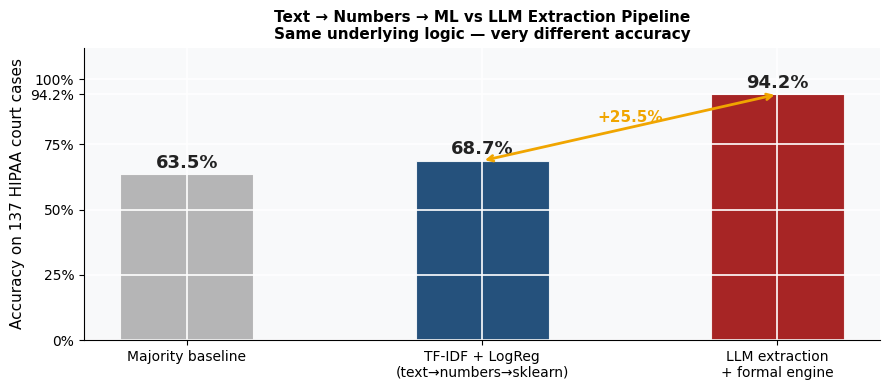


  Gap: 25.5%
  → This gap is why we need NLP, embeddings, and LLMs.
  → The rest of this week closes that gap step by step.


In [47]:
# Compare text-based vs LLM-based accuracy
texts  = hipaa['question'].fillna('').tolist()
y_hip  = (hipaa['ground_truth'] == 'PERMITTED').astype(int).values

tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X_text = tfidf.fit_transform(texts)

lr_text = LogisticRegression(random_state=42)
acc_tfidf   = cross_val_score(lr_text, X_text, y_hip, cv=5, scoring='accuracy').mean()
acc_llm_eng = (hipaa['match'] == 'Y').mean()
acc_majority = max(y_hip.mean(), 1 - y_hip.mean())

methods = ['Majority baseline', 'TF-IDF + LogReg\n(text→numbers→sklearn)', 'LLM extraction\n+ formal engine']
accs    = [acc_majority, acc_tfidf, acc_llm_eng]
colors_hip = ['#aaa', C_NO, C_YES]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(methods, accs, color=colors_hip, alpha=0.85, width=0.45,
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=13, fontweight='bold', color='#222')

ax.set_ylim(0, 1.12)
ax.set_ylabel('Accuracy on 137 HIPAA court cases', fontsize=11)
ax.set_title('Text → Numbers → ML vs LLM Extraction Pipeline\nSame underlying logic — very different accuracy',
             fontsize=11, fontweight='bold')
ax.set_yticks([0, 0.25, 0.5, 0.75, 0.9416, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '94.2%', '100%'])

# Gap annotation
gap = acc_llm_eng - acc_tfidf
ax.annotate('', xy=(2, acc_llm_eng), xytext=(1, acc_tfidf),
            arrowprops=dict(arrowstyle='<->', color=C_GOLD, lw=2))
ax.text(1.5, (acc_llm_eng + acc_tfidf)/2 + 0.02,
        f'+{gap:.1%}', ha='center', fontsize=11, fontweight='bold', color=C_GOLD)

plt.tight_layout()
plt.show()
print()
print(f'  Gap: {gap:.1%}')
print('  → This gap is why we need NLP, embeddings, and LLMs.')
print('  → The rest of this week closes that gap step by step.')

---
## Summary

| Concept | Visual you saw | Key takeaway |
|---|---|---|
| **Features & Labels** | Scatter plots | Even by eye the classes cluster — ML formalizes this |
| **Decision Tree** | Tree diagram | Reads like a flowchart — fully explainable |
| **Logistic Regression** | Weight bar chart | Positive = pushes toward prediction; magnitude = strength |
| **Random Forest** | Importance chart | 100 trees vote; importance = usefulness across all splits |
| **Confusion Matrix** | 3-model heatmaps | FP vs FN are different errors with different consequences |
| **The wall** | Accuracy bar chart | Text → TF-IDF → ML = 70%. LLM extraction = 94.2%. The gap is why NLP matters. |

> **Transition:** "Tomorrow: three ways to turn text into numbers — Bag of Words, TF-IDF, and embeddings. Each one closes part of that gap. Each one also hits a wall. Your job this week is to understand every wall and why LLMs are the current best answer to them."